In [36]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_openrouter import ChatOpenRouter

from pydantic import BaseModel,Field
from dotenv import load_dotenv
from typing import TypedDict,Optional,Literal,List,Annotated
import operator
import os

from langgraph.graph import StateGraph,START,END

load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langgraph-multi-query-agent"


In [37]:
class AgentState(TypedDict):
    user_query:str
    enhanced_query:str
    classify_query:Literal['technical','informational','analytical']
    research_response:Annotated[List[str],operator.add]
    example_response:Annotated[List[str],operator.add]
    summary_response:Annotated[List[str],operator.add]
    final_response:Annotated[List[str],operator.add]
    evaluator_response:Annotated[List[Literal['approved','need_improvement']],operator.add]
    iteration:1
    

In [38]:
# pydantic structure for the model
class classify_query_structure(BaseModel):
    classification:Literal['technical','informational','analytical']=Field(description='''for the given query classify which type of the query is it? 
    Technical:
        Programming
        Algorithms
        Math / formulas
        Engineering concepts
        System design
        
    Informational (General Knowledge):
        Objective, fact-based queries (no opinion needed)
        Definitions
        Explanations
        History
        Concepts
        
    Opinion / Analytical:
        Requires reasoning, judgment, or comparison
        Debates
        Pros/cons
        Recommendations
        Subjective answers
    ''')
    
    
class Evaluator_Structure(BaseModel):
    result:Literal['approved','need_improvement']=Field(description='evaluate the output provided by the model with the user input provided. approve only it everything meets the requirements else return need_improvement')
    


In [39]:
# define objects for the classes

# parsers: 
parser=StrOutputParser()

# models

enhance_query_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
classify_query_model=ChatGroq(model='llama-3.1-8b-instant')
technical_research_model=ChatGroq(model='llama-3.1-8b-instant')

technical_llm=HuggingFaceEndpoint(repo_id="openai/gpt-oss-120b",task="text-generation",)
technical_example_model = ChatHuggingFace(llm=technical_llm)
technical_summary_model=ChatOpenRouter(model='openrouter/free')

informational_llm=HuggingFaceEndpoint(repo_id="MiniMaxAI/MiniMax-M2.7",task="text-generation",)
informational_example_model = ChatHuggingFace(llm=technical_llm)
informational_summary_model=ChatOpenRouter(model='openrouter/free')

analytical_llm=HuggingFaceEndpoint(repo_id="meta-llama/Llama-3.1-8B-Instruct",task="text-generation",)
analytical_example_model = ChatHuggingFace(llm=technical_llm)
analytical_summary_model=ChatOpenRouter(model='openrouter/free')

output_structure_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash')

evaluator_model=ChatGroq(model='llama-3.1-8b-instant')

In [ ]:
# Node Functions

def enhance_query(state: AgentState):
    user_input = state['user_query']
    prompt = PromptTemplate(
        template=(
            "Rewrite the user query to be clearer, more specific, and easier to answer.\n"
            "Preserve the original intent.\n\n"
            "User query: {user_input}\n\n"
            "Rewritten query:"
        ),
        input_variables=['user_input']
    )
    chain = prompt | enhance_query_model | parser
    response = chain.invoke({
        'user_input': user_input
    })
    return {'enhanced_query': response}


def classify_query(state: AgentState):
    query = state['enhanced_query']
    prompt = PromptTemplate(
        template=(
            "Classify the query into exactly one of these categories: technical, informational, analytical.\n"
            "Return only the category label.\n\n"
            "Query: {query}"
        ),
        input_variables=['query']
    )
    chain = prompt | classify_query_model
    response = chain.invoke({'query': query})
    return {'classify_query': response.classification}


def classfication_condition(state: AgentState) -> Literal['technical_handler', 'informational_handler', 'analytical_handler']:
    classification = state['classify_query']

    if classification == 'technical':
        return 'technical_handler'
    elif classification == 'informational':
        return 'informational_handler'
    else:
        return 'analytical_handler'



def technical_handler(state: AgentState):
    return {}


def technical_research(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Answer the following technical query with concise research-oriented guidance.\n\n"
            "Query: {query}\n\n"
            "Research response:"
        ),
        input_variables=['query']
    )
    chain = prompt | technical_research_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'research_response': [response]}


def technical_example(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Provide one clear technical example for the query below.\n\n"
            "Query: {query}\n\n"
            "Example:"
        ),
        input_variables=['query']
    )
    chain = prompt | technical_example_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'example_response': [response]}


def technical_summary(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Summarize the technical answer in a short, useful final summary.\n\n"
            "Query: {query}\n\n"
            "Summary:"
        ),
        input_variables=['query']
    )
    chain = prompt | technical_summary_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'summary_response': [response]}



def informational_handler(state: AgentState):
    return {}


def informational_research(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Answer the following informational query with accurate, factual background.\n\n"
            "Query: {query}\n\n"
            "Research response:"
        ),
        input_variables=['query']
    )
    chain = prompt | informational_example_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'research_response': [response]}


def informational_example(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Provide one practical example that illustrates the informational topic below.\n\n"
            "Query: {query}\n\n"
            "Example:"
        ),
        input_variables=['query']
    )
    chain = prompt | informational_example_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'example_response': [response]}


def informational_summary(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Summarize the informational answer clearly and briefly.\n\n"
            "Query: {query}\n\n"
            "Summary:"
        ),
        input_variables=['query']
    )
    chain = prompt | informational_summary_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'summary_response': [response]}



def analytical_handler(state: AgentState):
    return {}


def analytical_research(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Analyze the query and provide reasoned, balanced research.\n\n"
            "Query: {query}\n\n"
            "Research response:"
        ),
        input_variables=['query']
    )
    chain = prompt | analytical_example_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'research_response': [response]}


def analytical_example(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Provide an example or comparison that supports the analytical answer below.\n\n"
            "Query: {query}\n\n"
            "Example:"
        ),
        input_variables=['query']
    )
    chain = prompt | analytical_example_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'example_response': [response]}


def analytical_summary(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Write a concise final summary with the main analytical conclusion.\n\n"
            "Query: {query}\n\n"
            "Summary:"
        ),
        input_variables=['query']
    )
    chain = prompt | analytical_summary_model | parser
    response = chain.invoke({'query': state['enhanced_query']})
    return {'summary_response': [response]}



def combine_output(state: AgentState):
    research_response = state.get('research_response', [])
    example_response = state.get('example_response', [])
    summary_response = state.get('summary_response', [])

    combined_response = "\n\n".join([
        "Research:\n" + "\n".join(research_response) if research_response else "Research:\n",
        "Example:\n" + "\n".join(example_response) if example_response else "Example:\n",
        "Summary:\n" + "\n".join(summary_response) if summary_response else "Summary:\n",
    ])
    return {'final_response': [combined_response]}


def evaluate_output(state: AgentState):
    prompt = PromptTemplate(
        template=(
            "Evaluate whether the response fully addresses the user query.\n"
            "Return approved if the answer is complete, accurate, and relevant.\n"
            "Return need_improvement otherwise.\n\n"
            "User query: {query}\n\n"
            "Draft response: {response}"
        ),
        input_variables=['query', 'response']
    )
    chain = prompt | evaluator_model
    response = chain.invoke({
        'query': state['enhanced_query'],
        'response': '\n\n'.join(state.get('final_response', []))
    })
    return {'evaluator_response': [response.result]}


def evaluation_condition(state: AgentState) -> Literal['approved', 'need_improvement']:
    evaluation = state['evaluator_response']
    return evaluation[-1] if evaluation else 'need_improvement'


In [41]:
# graph Structure

graph=StateGraph(state_schema=AgentState)


graph.add_node('enhance_query',enhance_query)
graph.add_node('classify_query',classify_query)

graph.add_node('technical_handler',technical_handler)
graph.add_node('informational_handler',informational_handler)
graph.add_node('analytical_handler',analytical_handler)

graph.add_node('technical_research',technical_research)
graph.add_node('technical_example',technical_example)
graph.add_node('technical_summary',technical_summary)

graph.add_node('informational_research',informational_research)
graph.add_node('informational_example',informational_example)
graph.add_node('informational_summary',informational_summary)

graph.add_node('analytical_research',analytical_research)
graph.add_node('analytical_example',analytical_example)
graph.add_node('analytical_summary',analytical_summary)

graph.add_node('combine_output',combine_output)

graph.add_node('evaluate_output',evaluate_output)




# forming edges
graph.add_edge(start_key=START,end_key='enhance_query')
graph.add_edge(start_key='enhance_query',end_key='classify_query')
graph.add_conditional_edges(
    source='classify_query',
    path=classfication_condition,
    path_map={
        'technical':'technical_handler',
        'informational':'informational_handler',
        'analytical':'analytical_handler'
    }
)
graph.add_edge('technical_handler','technical_research')
graph.add_edge('technical_handler','technical_example')
graph.add_edge('technical_handler','technical_summary')

graph.add_edge('technical_research','combine_output')
graph.add_edge('technical_example','combine_output')
graph.add_edge('technical_summary','combine_output')




graph.add_edge('informational_handler','informational_research')
graph.add_edge('informational_handler','informational_example')
graph.add_edge('informational_handler','informational_summary')

graph.add_edge('informational_research','combine_output')
graph.add_edge('informational_example','combine_output')
graph.add_edge('informational_summary','combine_output')




graph.add_edge('analytical_handler','analytical_research')
graph.add_edge('analytical_handler','analytical_example')
graph.add_edge('analytical_handler','analytical_summary')

graph.add_edge('analytical_research','combine_output')
graph.add_edge('analytical_example','combine_output')
graph.add_edge('analytical_summary','combine_output')

graph.add_edge('combine_output','evaluate_output')



graph.add_conditional_edges(
    source='evaluate_output',
    path=evaluation_condition,
    path_map={
        'approved':END,
        'need_improvement':'classify_query'
    }
)

workflow=graph.compile()

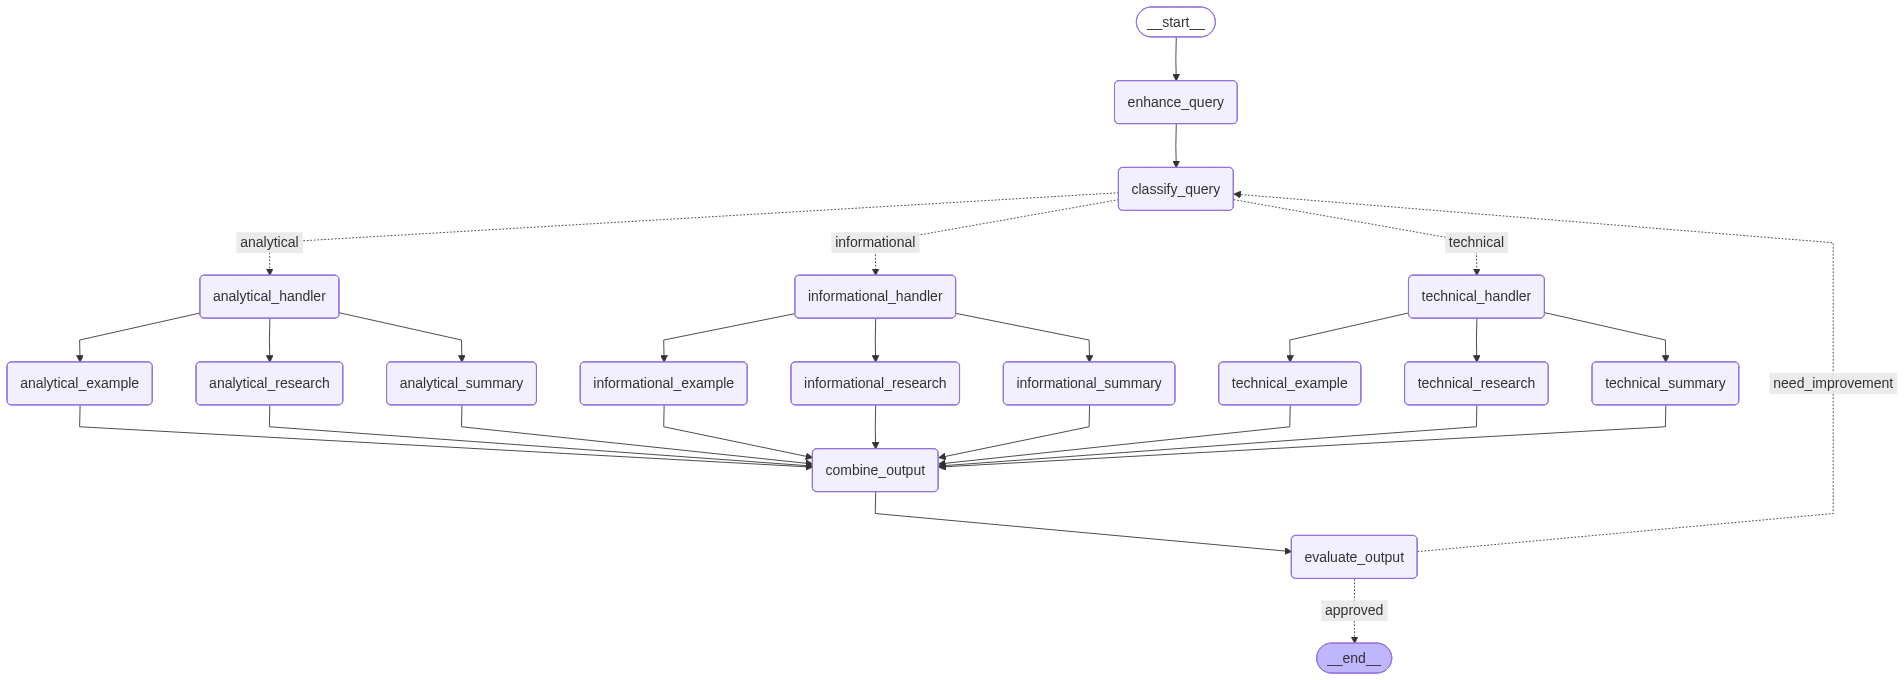

In [42]:
workflow

In [43]:
response=workflow.invoke({
    'user_query':"Can you explain the concept of overfitting in machine learning and provide an example?"
})

AttributeError: 'AIMessage' object has no attribute 'classification'